# Laboratorio 3 - Reconocimiento de Lenguaje de Señas (ASL)
## CC3084 - Data Science, UVG

SignBridge es una startup guatemalteca que quiere construir un traductor de Lenguaje de Señas Americano (ASL) en tiempo real. En este laboratorio construimos y evaluamos un primer prototipo del motor de reconocimiento: un clasificador de letras del alfabeto ASL a partir de imágenes de manos, usando el dataset [ASL Alphabet de Kaggle](https://www.kaggle.com/datasets/grassknoted/asl-alphabet).

## Importando los paquetes necesarios

In [2]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array

## Cargando el conjunto de datos

In [3]:
train_dir = "archive/asl_alphabet_train/asl_alphabet_train/"
test_dir = "archive/asl_alphabet_test/asl_alphabet_test/"

clases = sorted(os.listdir(train_dir))
print("Cantidad de clases:", len(clases))
print(clases)

Cantidad de clases: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## Ejercicio 1: Ejemplos de letras del alfabeto ASL

Mostramos 5 letras distintas con varias muestras cada una, para observar la variabilidad dentro de una misma clase.

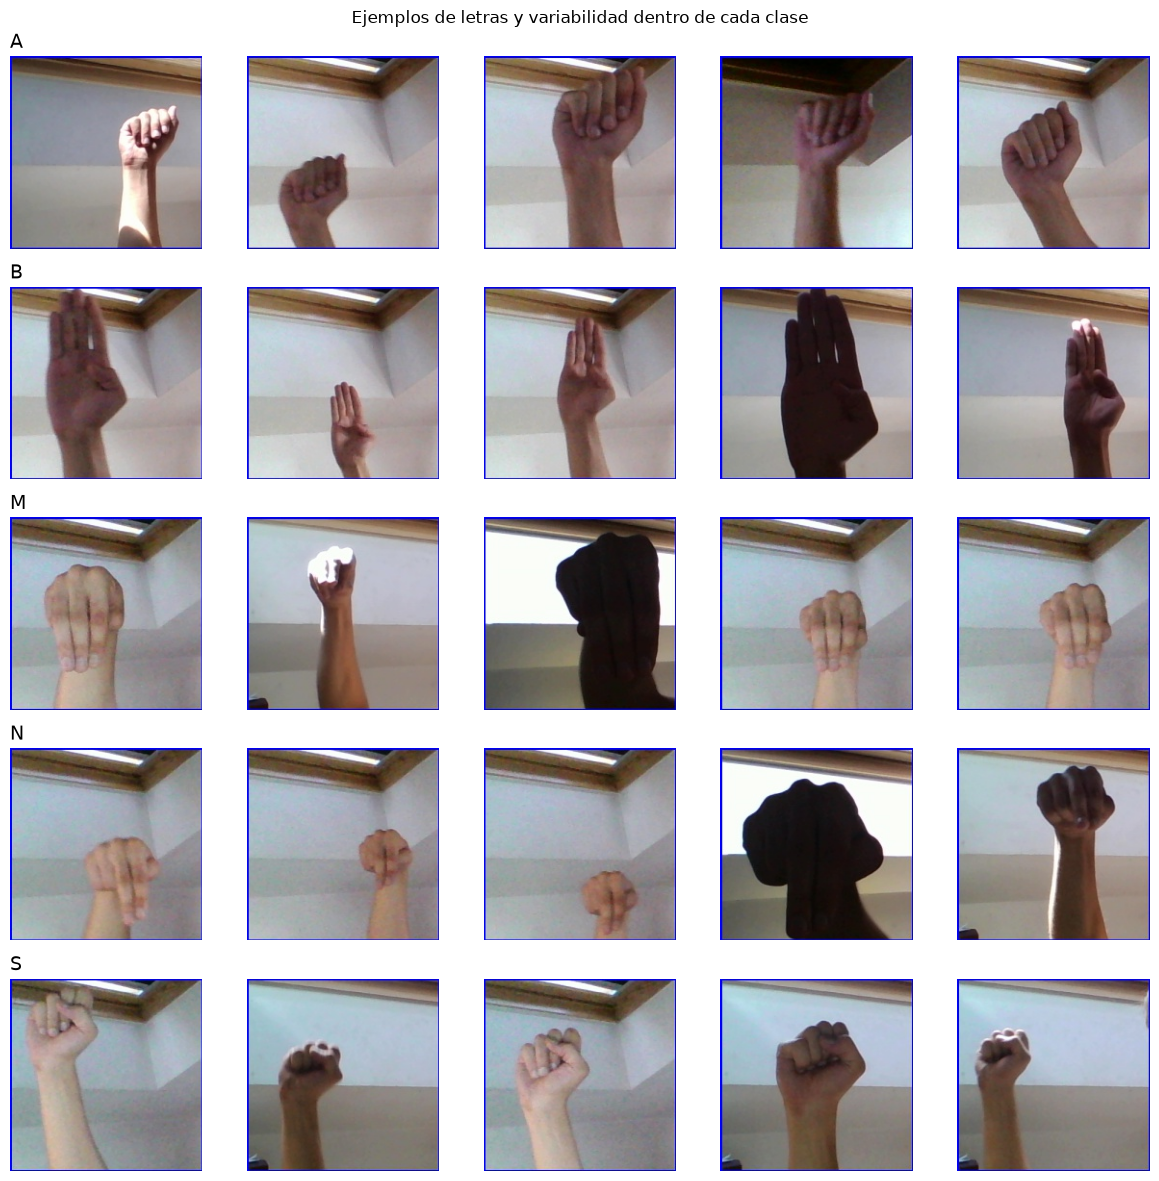

In [4]:
random.seed(42)
letras_ejemplo = ["A", "B", "M", "N", "S"]
muestras_por_letra = 5

fig, axes = plt.subplots(len(letras_ejemplo), muestras_por_letra, figsize=(12, 12))
for i, letra in enumerate(letras_ejemplo):
    archivos = os.listdir(train_dir + letra)
    seleccion = random.sample(archivos, muestras_por_letra)
    for j, archivo in enumerate(seleccion):
        imagen = imread(train_dir + letra + "/" + archivo)
        axes[i, j].imshow(imagen)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(letra, fontsize=14, loc="left")

plt.suptitle("Ejemplos de letras y variabilidad dentro de cada clase")
plt.tight_layout()
plt.show()

Dentro de una misma letra las fotos varían en iluminación, posición de la mano dentro del cuadro y fondo, aunque todas fueron tomadas en un set up similar (misma persona, mismo fondo por sesión de captura).

## Ejercicio 2: Análisis exploratorio de los datos

### Resolución y formato de las imágenes

In [5]:
resoluciones = set()
formatos = set()
modos = set()

for letra in clases:
    archivos = os.listdir(train_dir + letra)[:5]
    for archivo in archivos:
        img = Image.open(train_dir + letra + "/" + archivo)
        resoluciones.add(img.size)
        formatos.add(img.format)
        modos.add(img.mode)

print("Resoluciones encontradas:", resoluciones)
print("Formatos encontrados:", formatos)
print("Modos de color encontrados:", modos)

Resoluciones encontradas: {(200, 200)}
Formatos encontrados: {'JPEG'}
Modos de color encontrados: {'RGB'}


Todas las imágenes revisadas son archivos `.jpg` de 200x200 píxeles en color (RGB), consistente con lo que describe el dataset en Kaggle.

### Distribución de clases

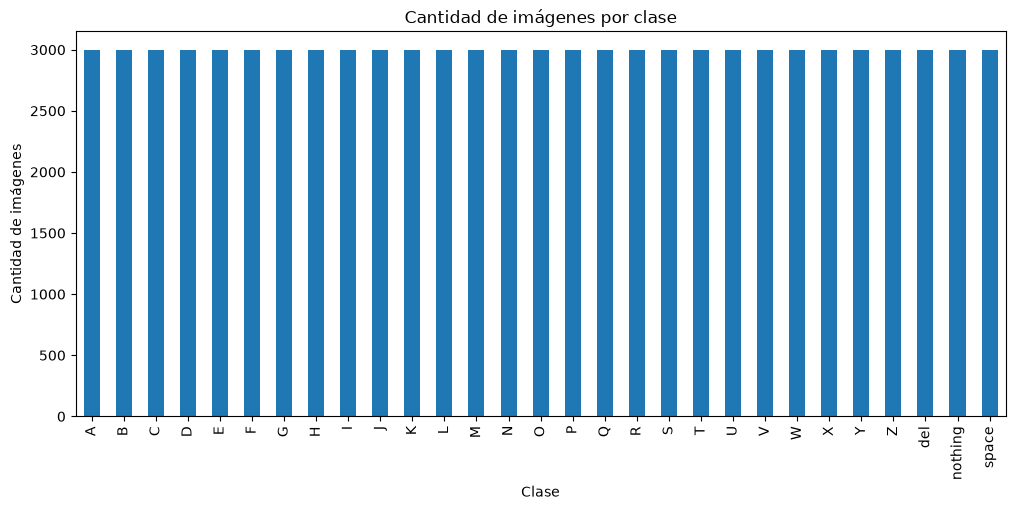

count      29.0
mean     3000.0
std         0.0
min      3000.0
25%      3000.0
50%      3000.0
75%      3000.0
max      3000.0
dtype: float64

In [6]:
conteo_clases = {letra: len(os.listdir(train_dir + letra)) for letra in clases}
conteo_clases = pd.Series(conteo_clases).sort_index()

plt.figure(figsize=(12, 5))
conteo_clases.plot(kind="bar")
plt.title("Cantidad de imágenes por clase")
plt.ylabel("Cantidad de imágenes")
plt.xlabel("Clase")
plt.show()

conteo_clases.describe()

El dataset está balanceado: las 29 clases (A-Z, `space`, `del`, `nothing`) tienen 3,000 imágenes cada una, para un total de 87,000 imágenes de entrenamiento.

### Letras que se confunden visualmente

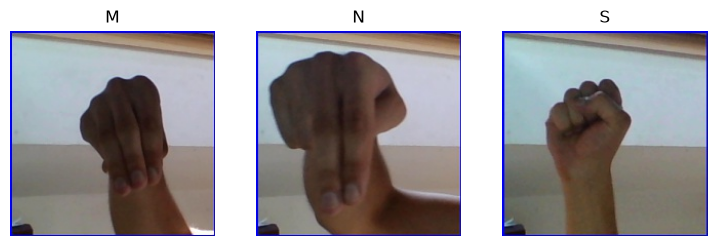

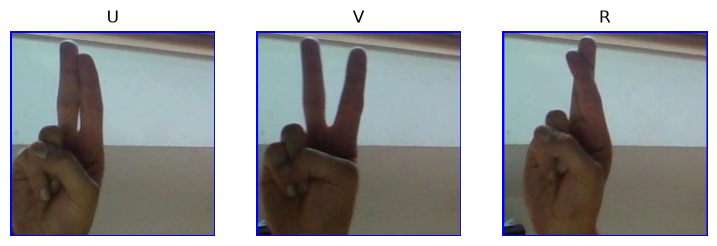

In [7]:
grupos_confusos = [["M", "N", "S"], ["U", "V", "R"]]

for grupo in grupos_confusos:
    fig, axes = plt.subplots(1, len(grupo), figsize=(9, 3))
    for ax, letra in zip(axes, grupo):
        archivo = os.listdir(train_dir + letra)[0]
        imagen = imread(train_dir + letra + "/" + archivo)
        ax.imshow(imagen)
        ax.set_title(letra)
        ax.axis("off")
    plt.show()

**M/N/S**: las tres son puños cerrados, la diferencia está en la posición del pulgar (debajo de dos dedos, debajo de un dedo, o cruzado al frente), un detalle fino que un modelo puede pasar por alto fácilmente.

**U/V/R**: las tres muestran dos dedos extendidos, la diferencia está en si están juntos (U), separados en V, o cruzados (R). También es una diferencia sutil de la posición relativa de los dedos más que de la forma general de la mano.

Estas letras son las candidatas más probables a confusión en la matriz de confusión de los modelos.

### Definición del conjunto de entrenamiento/validación/prueba

El set de prueba oficial de Kaggle solo trae 1 imagen por clase (29 en total), insuficiente para evaluar el modelo. Por lo tanto construimos nuestro propio split a partir de las imágenes de entrenamiento.

Por el costo computacional de cargar 87,000 imágenes de 200x200 a color, tomamos una submuestra de 600 imágenes por clase (17,400 imágenes en total, ~20% del dataset completo), suficiente para entrenar y comparar modelos sin agotar la memoria disponible. Dividimos esa submuestra en 70% entrenamiento, 15% validación y 15% prueba, de forma estratificada para mantener el balance de clases en los tres conjuntos.

In [8]:
random.seed(42)
muestras_por_clase = 600

rutas = []
etiquetas = []
for letra in clases:
    archivos = os.listdir(train_dir + letra)
    seleccion = random.sample(archivos, muestras_por_clase)
    for archivo in seleccion:
        rutas.append(train_dir + letra + "/" + archivo)
        etiquetas.append(letra)

datos = pd.DataFrame({"ruta": rutas, "etiqueta": etiquetas})
print(datos.shape)
datos.head()

(17400, 2)


,ruta,etiqueta
0,archive/asl_alphabet_train/asl_alphabet_train/...,A
1,archive/asl_alphabet_train/asl_alphabet_train/...,A
2,archive/asl_alphabet_train/asl_alphabet_train/...,A
3,archive/asl_alphabet_train/asl_alphabet_train/...,A
4,archive/asl_alphabet_train/asl_alphabet_train/...,A


In [9]:
train_df, temp_df = train_test_split(datos, test_size=0.3, stratify=datos["etiqueta"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["etiqueta"], random_state=42)

print("Entrenamiento:", train_df.shape[0])
print("Validación:", val_df.shape[0])
print("Prueba:", test_df.shape[0])

Entrenamiento: 12180
Validación: 2610
Prueba: 2610


## Ejercicio 3: Preprocesamiento de las imágenes

Antes de entrenar reducimos la resolución de 200x200 a 64x64 (menos parámetros y entrenamiento más rápido, sin perder la forma general de la mano) y normalizamos los píxeles a un rango de 0 a 1. No aplicamos filtros adicionales (por ejemplo escala de grises) porque el color puede ayudar al modelo a separar la mano del fondo.

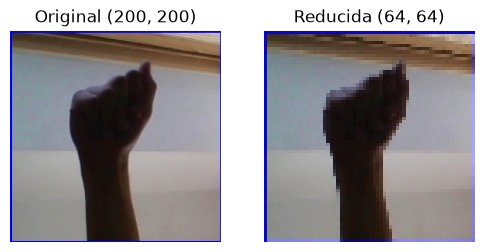

In [10]:
ejemplo_original = imread(train_dir + "A/" + os.listdir(train_dir + "A")[0])
ejemplo_reducido = img_to_array(load_img(train_dir + "A/" + os.listdir(train_dir + "A")[0], target_size=(64, 64)))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(ejemplo_original)
axes[0].set_title(f"Original {ejemplo_original.shape[:2]}")
axes[0].axis("off")
axes[1].imshow(ejemplo_reducido.astype("uint8"))
axes[1].set_title(f"Reducida {ejemplo_reducido.shape[:2]}")
axes[1].axis("off")
plt.show()

In [11]:
tamano_imagen = 64

def cargar_y_procesar(df):
    imagenes = []
    for ruta in df["ruta"]:
        imagen = load_img(ruta, target_size=(tamano_imagen, tamano_imagen))
        imagenes.append(img_to_array(imagen))
    return np.asarray(imagenes) / 255.0

X_train = cargar_y_procesar(train_df)
X_val = cargar_y_procesar(val_df)
X_test = cargar_y_procesar(test_df)

print(X_train.shape, X_val.shape, X_test.shape)
print("Rango de valores:", X_train.min(), "-", X_train.max())

(12180, 64, 64, 3) (2610, 64, 64, 3) (2610, 64, 64, 3)
Rango de valores: 0.0 - 1.0


In [12]:
etiqueta_a_indice = {letra: i for i, letra in enumerate(clases)}

y_train = train_df["etiqueta"].map(etiqueta_a_indice).values
y_val = val_df["etiqueta"].map(etiqueta_a_indice).values
y_test = test_df["etiqueta"].map(etiqueta_a_indice).values

print(y_train.shape, y_val.shape, y_test.shape)

(12180,) (2610,) (2610,)


## Plan de modelos

### Redes neuronales convolucionales (CNN)

Vamos a construir al menos 2 modelos de CNN sobre las imágenes de 64x64x3 preprocesadas, variando la profundidad y la regularización para comparar resultados:

- **CNN 1 (base)**: un bloque convolucional (Conv2D + MaxPooling) seguido de capas densas, como punto de partida.
- **CNN 2 (más profunda)**: dos o tres bloques convolucionales para ver si más profundidad mejora la exactitud, similar a una arquitectura VGG pequeña.
- Variaciones adicionales a probar entre esos modelos: dropout para controlar overfitting, cambios en el learning rate y en la cantidad de épocas.

El mejor modelo se selecciona comparando exactitud y pérdida en el set de validación.

### Red neuronal simple (fully-connected)

Además de las CNN vamos a entrenar una red fully-connected (sin capas convolucionales) sobre las mismas imágenes de 64x64x3 aplanadas a un vector. Sirve como punto de comparación: al no tener capas convolucionales, no aprovecha la estructura espacial de la imagen (relación entre píxeles vecinos), así que esperamos que le cueste más separar señas visualmente parecidas (M/N/S, U/V/R) que a las CNN.

### Otro algoritmo

Como tercer enfoque vamos a probar **Random Forest** sobre las imágenes aplanadas (o sobre una versión reducida, por ejemplo con PCA, si el número de píxeles resulta muy alto para entrenarlo en un tiempo razonable). Lo elegimos porque es rápido de entrenar, no necesita GPU, y nos da una referencia de qué tanto se puede resolver el problema sin usar redes neuronales, además de ofrecer una medida de importancia de variables (píxeles) que puede ser interesante de interpretar.

## Ejercicio 4: Modelos de Deep Learning (CNN)

### CNN 1 (modelo base)

In [12]:
from tensorflow import keras

num_clases = len(clases)

# Modelo base: un bloque conv + maxpooling, seguido de capas densas
modelo1 = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(tamano_imagen, tamano_imagen, 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(num_clases, activation="softmax"),
])

modelo1.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
modelo1.summary()

C:\Users\hugob\OneDrive\Desktop\clases\data_science\Laboratorio-3-data-science\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,199,069 (16.02 MB)

 Trainable params: 4,199,069 (16.02 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history1 = modelo1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
)

Epoch 1/10


  1/381 ━━━━━━━━━━━━━━━━━━━━ 4:48 759ms/step - accuracy: 0.0000e+00 - loss: 3.4121

  5/381 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0188 - loss: 5.5801       

  9/381 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.0208 - loss: 4.8654

 13/381 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.0192 - loss: 4.5662

...

370/381 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8481 - loss: 0.4952

374/381 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8478 - loss: 0.4957

377/381 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8476 - loss: 0.4959

381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8480 - loss: 0.4957

381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8480 - loss: 0.4957 - val_accuracy: 0.7640 - val_loss: 0.7196


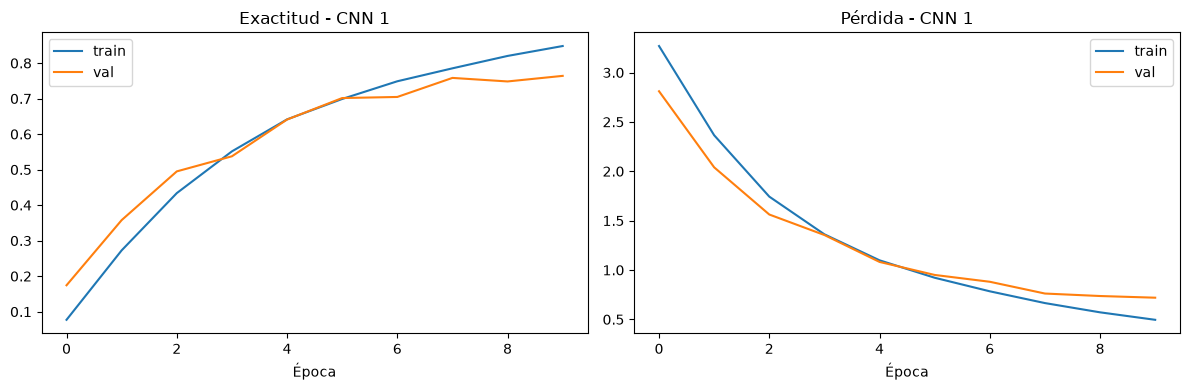

CNN 1 - Validación: accuracy=0.7640, loss=0.7196


In [14]:
# Curvas de exactitud y pérdida
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history1.history["accuracy"], label="train")
axes[0].plot(history1.history["val_accuracy"], label="val")
axes[0].set_title("Exactitud - CNN 1")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history1.history["loss"], label="train")
axes[1].plot(history1.history["val_loss"], label="val")
axes[1].set_title("Pérdida - CNN 1")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

val_loss1, val_acc1 = modelo1.evaluate(X_val, y_val, verbose=0)
print(f"CNN 1 - Validación: accuracy={val_acc1:.4f}, loss={val_loss1:.4f}")